 # Underwater Image Denoising Demo

This notebook applies a **multi-stage denoising pipeline** to a single image.

Pipeline (in order):

1. Gaussian smoothing – remove high-frequency sensor noise.  
2. Median filtering – remove salt-and-pepper / particle speckle.  
3. Bilateral filtering (optional) – smooth homogeneous water regions while preserving edges.  
4. Laplacian high-boost sharpening – restore edge sharpness after smoothing.

Edit the `INPUT_IMAGE` and `OUTPUT_IMAGE` paths in the cell below, then run all cells.


In [3]:
# If you don't have these installed yet, run in a terminal:
# pip install opencv-python numpy matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_image(img, title=None, figsize=(6, 5)):
    """Utility to display BGR image with matplotlib."""
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()


In [9]:
# ---- Denoising functions (Gaussian -> Median -> Bilateral -> Sharpen) ----

def gaussian_smooth(img, ksize=5, sigma=1.5):
    """Initial smoothing to remove high-frequency sensor noise."""
    ksize = int(ksize) | 1  # make sure it's odd
    return cv2.GaussianBlur(img, (ksize, ksize), sigmaX=sigma, sigmaY=sigma)

def median_filter(img, ksize=3):
    """Remove salt-and-pepper style particle noise while preserving edges."""
    ksize = int(ksize) | 1
    return cv2.medianBlur(img, ksize)

def bilateral_filter_optional(img, d=0, sigma_color=25, sigma_space=None):
    """
    Edge-preserving smoothing.
    If d <= 0, returns img unchanged (i.e., skip this step).
    """
    if d is None or d <= 0:
        return img
    if sigma_space is None:
        sigma_space = max(10, d * 2)
    return cv2.bilateralFilter(img, d=d, sigmaColor=sigma_color, sigmaSpace=sigma_space)

def laplacian_highboost(img, strength=0.3):
    """Recover edge sharpness after smoothing by subtracting scaled Laplacian."""
    if strength <= 0:
        return img
    f = img.astype(np.float32)
    lap = cv2.Laplacian(f, ddepth=cv2.CV_32F, ksize=3)
    out = f - strength * lap
    return np.clip(out, 0, 255).astype(np.uint8)
 
def remove_big_spots(img_bgr, thresh=220, k=5):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, thresh, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
    mask_clean = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    inpainted = cv2.inpaint(img_bgr, mask_clean, 3, cv2.INPAINT_TELEA)
    return inpainted


In [ ]:
INPUT_IMAGE = "../data/UnderwaterImageSamples/fish/0001 3.jpg"
OUTPUT_IMAGE = "output_denoised.jpg"

print("Input image path: ", INPUT_IMAGE)
print("Output image path:", OUTPUT_IMAGE)

Input image path:  ../data/UnderwaterImageSamples/fish/0001 3.jpg
Output image path: output_denoised2.jpg


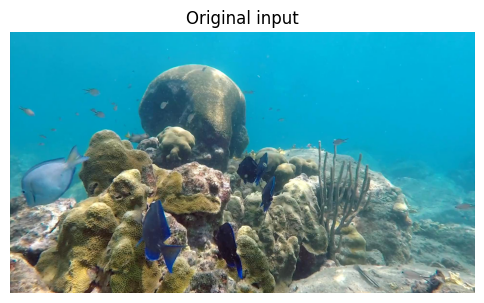

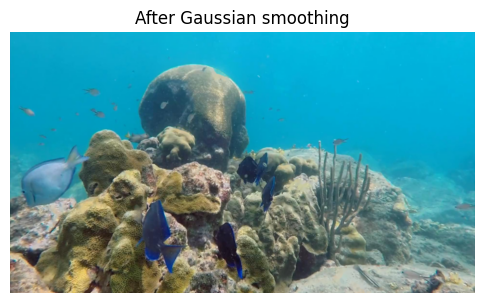

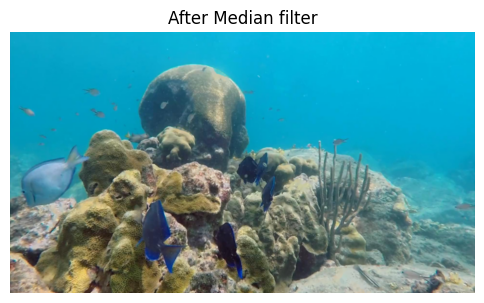

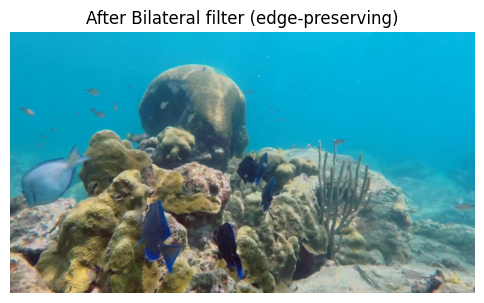

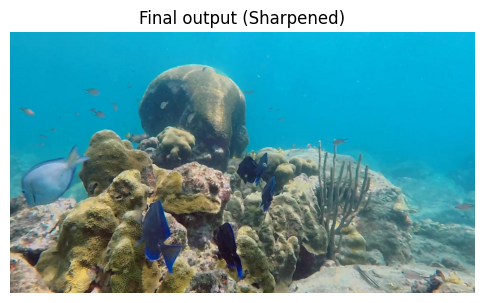

Saved denoised image to: output_denoised2.jpg


In [ ]:
# 1. Load
img = cv2.imread(INPUT_IMAGE, cv2.IMREAD_COLOR)
if img is None:
    raise FileNotFoundError(f"Could not read image at: {INPUT_IMAGE}")

show_image(img, "Original input")
# remove big spots if any
img = remove_big_spots(img, thresh=200, k=5)

# 2. Gaussian smoothing
g = gaussian_smooth(img, ksize=5, sigma=1.5)
show_image(g, "After Gaussian smoothing")
cv2.imwrite("after_gaussian.jpg", g)

# 3. Median filtering
m = median_filter(g, ksize=3)
show_image(m, "After Median filter")
cv2.imwrite("after_median.jpg", m)

# 4. Bilateral (optional) - set d to 0 to skip
b = bilateral_filter_optional(m, d=7, sigma_color=25)
show_image(b, "After Bilateral filter (edge-preserving)")
cv2.imwrite("after_bilateral.jpg", b)

# 5. Sharpen
out = laplacian_highboost(b, strength=0.3)
show_image(out, "Final output (Sharpened)")

# 6. Save
cv2.imwrite(OUTPUT_IMAGE, out)
print("Saved denoised image to:", OUTPUT_IMAGE)
